## SOABB1 - SCRIPT 4:
Aim: visualise f0 variation over time

In [2]:
## CHANGE ON YOUR COMPUTER
user = "margherita"

In [3]:
## ## CHANGE ON YOUR COMPUTER
DIR_data = "/Users/" + user + "/Documents/SOABB_ETUDE1/audio_analysis/datasets/"

if (user == "fannie"):
    DIR = "/Users/" + user + "/Documents/GitHub/SOA-project-/datasets/"
elif user == "louise":
    DIR = "/Users/" + user + "/Documents/GitHub/SOA-project-/datasets/"
    DIR_data = "/Users/" + user + "/Documents/SOA_BB/SOABB_ETUDE1/audio_analysis/datasets/"
elif user == "margherita":
    DIR = r"C:/Users/Margherita/Desktop/SOA_Projet/" #windows address

current_file = DIR + "N72_f0_overtime.csv"
current_fileHNR = DIR_data + "N72_HNR_RMS_overtime.csv"

dtype_dict = {9: str}

excl_neutral = 0
if excl_neutral:
    condOrder = ["p100","m100"]
    condColor = ["turquoise", "orchid"]
else:
    condOrder = ["p100","m100", "neutre"]
    condColor = ["turquoise", "orchid", "Grey"]

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt
import matplotlib as mpl
import re
import os  
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
#from utilities import find_chunks, slice_tuple, run_permstats

In [5]:
# Define folder and file
df = pd.read_csv(current_file, sep = ";", dtype=dtype_dict)
df = df.drop(columns=['Unnamed: 0'])  # Suppression de la colonne 'Unnamed: 0'
df_bb = df#[df['who'] == 'B']

# open HNR/RMS files
#dfHR = pd.read_csv(current_fileHNR, sep = ";", dtype=dtype_dict)

# Create a repository for saving plots 
output_dir = DIR + "plot_f0/"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

max_time = df_bb['timepoint'].max()
max_f0 = df_bb['f0_BBvoc_NM'].max()
min_time = df_bb['timepoint'].min()
min_f0 = df_bb['f0_BBvoc_NM'].min()

df_bb.head()

C:\Users\Margherita\AppData\Local\Temp\ipykernel_21528\2524256966.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(current_file, sep = ";", dtype=dtype_dict)


,file,start_times,stop_times,who,cond,voc_type,phase,BBvoc_NM,BBvoc_M,BB,f0_BBvoc_NM,f0_BBvoc_M,timepoint,difference
0,BB1_6M_1403_p100_NM,38.01,38.79,B,p100,B,BL,/BB/BL/BB1_6M_1403_p100_NM_38.01_to_38.79,/BB/BL/BB1_6M_1403_p100_38.01_to_38.79_BL,1,NaN,NaN,0.001,NaN
1,BB1_6M_1403_p100_NM,38.01,38.79,B,p100,B,BL,/BB/BL/BB1_6M_1403_p100_NM_38.01_to_38.79,/BB/BL/BB1_6M_1403_p100_38.01_to_38.79_BL,1,NaN,NaN,0.002,NaN
2,BB1_6M_1403_p100_NM,38.01,38.79,B,p100,B,BL,/BB/BL/BB1_6M_1403_p100_NM_38.01_to_38.79,/BB/BL/BB1_6M_1403_p100_38.01_to_38.79_BL,1,NaN,NaN,0.003,NaN
3,BB1_6M_1403_p100_NM,38.01,38.79,B,p100,B,BL,/BB/BL/BB1_6M_1403_p100_NM_38.01_to_38.79,/BB/BL/BB1_6M_1403_p100_38.01_to_38.79_BL,1,NaN,NaN,0.004,NaN
4,BB1_6M_1403_p100_NM,38.01,38.79,B,p100,B,BL,/BB/BL/BB1_6M_1403_p100_NM_38.01_to_38.79,/BB/BL/BB1_6M_1403_p100_38.01_to_38.79_BL,1,NaN,NaN,0.005,NaN


In [6]:
df_bb.head()

,file,start_times,stop_times,who,cond,voc_type,phase,BBvoc_NM,BBvoc_M,BB,f0_BBvoc_NM,f0_BBvoc_M,timepoint,difference
0,BB1_6M_1403_p100_NM,38.01,38.79,B,p100,B,BL,/BB/BL/BB1_6M_1403_p100_NM_38.01_to_38.79,/BB/BL/BB1_6M_1403_p100_38.01_to_38.79_BL,1,NaN,NaN,0.001,NaN
1,BB1_6M_1403_p100_NM,38.01,38.79,B,p100,B,BL,/BB/BL/BB1_6M_1403_p100_NM_38.01_to_38.79,/BB/BL/BB1_6M_1403_p100_38.01_to_38.79_BL,1,NaN,NaN,0.002,NaN
2,BB1_6M_1403_p100_NM,38.01,38.79,B,p100,B,BL,/BB/BL/BB1_6M_1403_p100_NM_38.01_to_38.79,/BB/BL/BB1_6M_1403_p100_38.01_to_38.79_BL,1,NaN,NaN,0.003,NaN
3,BB1_6M_1403_p100_NM,38.01,38.79,B,p100,B,BL,/BB/BL/BB1_6M_1403_p100_NM_38.01_to_38.79,/BB/BL/BB1_6M_1403_p100_38.01_to_38.79_BL,1,NaN,NaN,0.004,NaN
4,BB1_6M_1403_p100_NM,38.01,38.79,B,p100,B,BL,/BB/BL/BB1_6M_1403_p100_NM_38.01_to_38.79,/BB/BL/BB1_6M_1403_p100_38.01_to_38.79_BL,1,NaN,NaN,0.005,NaN


## Create graphs to see the pitch by vocalisation

[ 29.766  37.106  45.198  47.012  48.708  50.978  53.011  57.066  61.142
  63.782  88.209  97.754 100.742 105.21  106.993 108.299 109.936 111.707
 140.727 142.396 147.396 150.093]


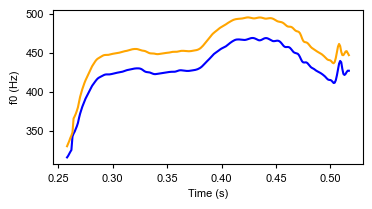

In [91]:
## Figure 1 - upward
# Publication-style defaults
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
## WHO ARE WE PLOTTING
X = 78

## finds start_times
print(np.unique(df_bb.loc[((df_bb["BB"] == X)), "start_times"])) #  & (df_bb["who"] == "B")

# which timing?
tt = 106.993

#### PLOTS DIRECTLY FROM THE FILE
#BBX = df_bb.loc[((df_bb["BB"] == X) & (df_bb["start_times"] == tt) & (df_bb["who"] == "B"))]
BBX = df_bb.loc[((df_bb["BB"] == X) & (df_bb["start_times"] == tt))]
plt.figure(figsize=(4.0, 2))
plt.plot(BBX['timepoint'], BBX["f0_BBvoc_NM"], label="Non-modified", color='blue')
plt.plot(BBX['timepoint'], BBX["f0_BBvoc_M"], label="Modifié (M)", color='orange')
plt.xlabel("Time (s)")
plt.ylabel("f0 (Hz)")
#plt.title(str(X), str(tt))

plt.savefig(output_dir + "UPWARD.pdf", format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)

plt.savefig(output_dir + "UPWARD.png", dpi=1000, format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)

plt.show()

[  1.841   9.011  11.988  18.844  21.958  32.771  72.689  74.238  77.259
  88.61   94.481  98.498 100.011 112.79  122.54  131.06  131.72  139.55
 142.72  143.53  144.55  146.87  154.34  156.27  159.63  160.69  169.93
 172.62  178.51  181.636 189.45  190.85  191.54  197.64  198.57  202.98
 209.27 ]


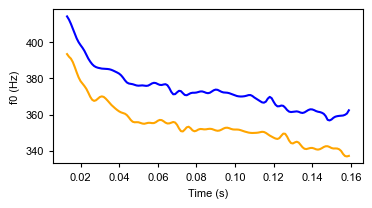

In [89]:
## Figure 2 - downward
# Publication-style defaults
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
## WHO ARE WE PLOTTING
X = 47

## finds start_times
print(np.unique(df_bb.loc[((df_bb["BB"] == X)), "start_times"])) #  & (df_bb["who"] == "B")

# which timing?
tt = 159.63

#### PLOTS DIRECTLY FROM THE FILE
#BBX = df_bb.loc[((df_bb["BB"] == X) & (df_bb["start_times"] == tt) & (df_bb["who"] == "B"))]
BBX = df_bb.loc[((df_bb["BB"] == X) & (df_bb["start_times"] == tt))]
plt.figure(figsize=(4.0, 2))
plt.plot(BBX['timepoint'], BBX["f0_BBvoc_NM"], label="Non-modified", color='blue')
plt.plot(BBX['timepoint'], BBX["f0_BBvoc_M"], label="Modifié (M)", color='orange')
plt.xlabel("Time (s)")
plt.ylabel("f0 (Hz)")
#plt.title(str(X), str(tt))

plt.savefig(output_dir + "DOWNWARD.pdf", format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)

plt.savefig(output_dir + "DOWNWARD.png", dpi=1000, format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)

plt.show()

[ 2.083939  3.87519   5.315216  6.614751  8.979671 33.869867 36.223079
 37.522614 40.777306 44.043705 44.757864 46.361795 49.253553 54.615599
 57.249792 58.853723 63.302582 65.10554  73.979844 78.194552 84.58686
 86.143961 87.431788 92.313826]


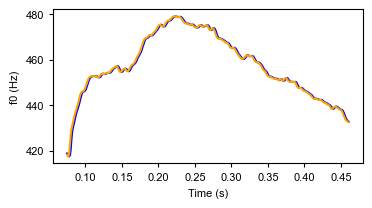

In [87]:
## Figure 2 - neutral
# Publication-style defaults
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
## WHO ARE WE PLOTTING
X = 121

## finds start_times
print(np.unique(df_bb.loc[((df_bb["BB"] == X)), "start_times"])) #  & (df_bb["who"] == "B")

# which timing?
tt = 92.313826      

#### PLOTS DIRECTLY FROM THE FILE
#BBX = df_bb.loc[((df_bb["BB"] == X) & (df_bb["start_times"] == tt) & (df_bb["who"] == "B"))]
BBX = df_bb.loc[((df_bb["BB"] == X) & (df_bb["start_times"] == tt))]
plt.figure(figsize=(4.0, 2))
plt.plot(BBX['timepoint'], BBX["f0_BBvoc_NM"], label="Non-modified", color='blue')
plt.plot(BBX['timepoint'], BBX["f0_BBvoc_M"], label="Modifié (M)", color='orange')
plt.xlabel("Time (s)")
plt.ylabel("f0 (Hz)")
#plt.title(str(X), str(tt))

plt.savefig(output_dir + "neutral.pdf", format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)

plt.savefig(output_dir + "neutral.png", dpi=1000, format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)

plt.show()

## Figure S2: visualise transformation by vocalisation type

[  3.512   4.713  26.99   31.222  35.492  42.495  55.991  57.63   73.038
  89.389  91.511  98.808 105.199 108.057 113.162 125.317 128.069 130.191
 132.987 137.904 139.477 140.817 147.    155.66  160.463 175.016 177.155
 178.796 179.511 179.742 185.566 193.372 197.38  205.289 207.689 210.992
 222.507 237.214 240.496 241.329 244.316 248.916 260.612 263.993 271.733
 281.099 294.055 297.297 305.918 308.051 309.18  310.287 312.898 318.686
 320.681 321.845 323.05  324.577 332.993 336.408 343.938 346.493 347.51
 354.792 358.467 361.746 369.355 373.511 380.71  390.511 392.676 395.007
 397.928 400.388 403.193]


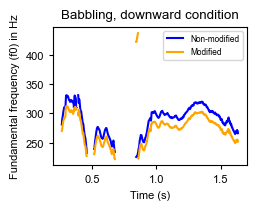

In [103]:
#### voc: BABBLING, cond: DOWNWARD ####
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

X = 90

## finds start_times
print(np.unique(df_bb.loc[((df_bb["BB"] == X)), "start_times"])) #  & (df_bb["who"] == "B")

# which timing?
tt = 403.193

#### PLOTS DIRECTLY FROM THE FILE
#BBX = df_bb.loc[((df_bb["BB"] == X) & (df_bb["start_times"] == tt) & (df_bb["who"] == "B"))]
BBX = df_bb.loc[((df_bb["BB"] == X) & (df_bb["start_times"] == tt))]
plt.figure(figsize=(2.5, 1.8))
plt.plot(BBX['timepoint'], BBX["f0_BBvoc_NM"], label="Non-modified", color='blue')
plt.plot(BBX['timepoint'], BBX["f0_BBvoc_M"], label="Modified", color='orange')
plt.title("Babbling, downward condition")
plt.xlabel("Time (s)")
plt.ylabel("Fundamental frequency (f0) in Hz")
plt.legend(loc="best")
plt.savefig(output_dir + "BABBLING_DOWN.pdf", dpi=1000, format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)
plt.savefig(output_dir + "BABBLING_DOWN.jpg", dpi=1000, format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)

[  0.         3.406223   5.825596   7.799295   9.566074  10.584758
  14.118316  16.680941  18.495471  21.233183  24.432486  24.957744
  28.539053  33.680221  37.850457  44.249062  44.93349   46.970857
  49.485732  51.459431  53.051124  55.327244  56.807519  58.988138
  60.993671  64.177057  66.771516  73.313374  74.172888  76.321673
  82.831697  84.869064  91.028916 106.65934  107.296017 112.341683
 117.562436 119.345132 121.095994 121.732671 124.120211 131.394247
 135.850987 138.811536 139.543714 142.201842 145.019138 147.931936
 151.974836 161.811498 163.76928  165.329139 171.536741 177.219085
 180.832228 183.681358 186.116648 192.976844 195.284799 197.831508
 208.479933 214.14636  217.664001 224.221776 226.816235 230.317959
 232.434911 241.030052 242.780914 244.229355 246.569144 248.415507
 249.768875 250.808896 251.260226 251.750802 252.70252  253.382525
 258.111679 260.309459 262.026475 266.814498 268.109618 269.453797
 270.709671 272.917263 278.235108 281.198187 287.036042 288.99

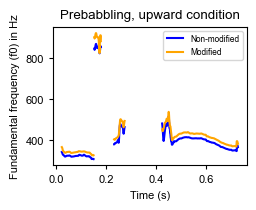

In [113]:
#### voc: PRE-BABBLING, cond: UPWARD ####
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

X = 148

## finds start_times
print(np.unique(df_bb.loc[((df_bb["BB"] == X)), "start_times"])) #  & (df_bb["who"] == "B")

# which timing?
tt = 591.499729 

#### PLOTS DIRECTLY FROM THE FILE
#BBX = df_bb.loc[((df_bb["BB"] == X) & (df_bb["start_times"] == tt) & (df_bb["who"] == "B"))]
BBX = df_bb.loc[((df_bb["BB"] == X) & (df_bb["start_times"] == tt))]
plt.figure(figsize=(2.5, 1.8))
plt.plot(BBX['timepoint'], BBX["f0_BBvoc_NM"], label="Non-modified", color='blue')
plt.plot(BBX['timepoint'], BBX["f0_BBvoc_M"], label="Modified", color='orange')
plt.title("Prebabbling, upward condition")
plt.xlabel("Time (s)")
plt.ylabel("Fundamental frequency (f0) in Hz")
plt.legend(loc="best")
plt.savefig(output_dir + "PREBABBLING_UP.pdf", dpi=1000, format=None, metadata=None,
           bbox_inches = "tight", pad_inches=0.1,
           facecolor='auto', edgecolor='auto',
           backend=None)
plt.savefig(output_dir + "PREBABBLING_UP.jpg", dpi=1000, format=None, metadata=None,
           bbox_inches = "tight", pad_inches=0.1,
           facecolor='auto', edgecolor='auto',
           backend=None)

[ 19.5    23.65   24.69  143.69  146.29  147.734 148.953 162.347 164.061
 167.497 175.287 176.104 178.757 191.154 196.265 201.049 211.16  222.607
 228.403 231.646 232.59  235.198 236.409 237.58  239.856 268.541 275.088
 281.022 289.358 295.613 334.45  337.84  338.674 342.033 364.751 365.983
 385.231 386.038 397.723 408.916 411.795]


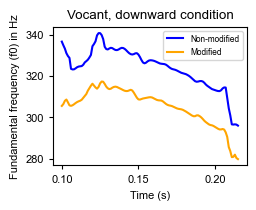

In [115]:
#### voc: VOCANT, cond: DOWNWARD ####
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

X = 96

## finds start_times
print(np.unique(df_bb.loc[((df_bb["BB"] == X)), "start_times"])) #  & (df_bb["who"] == "B")

# which timing?
tt = 337.84     

#### PLOTS DIRECTLY FROM THE FILE
#BBX = df_bb.loc[((df_bb["BB"] == X) & (df_bb["start_times"] == tt) & (df_bb["who"] == "B"))]
BBX = df_bb.loc[((df_bb["BB"] == X) & (df_bb["start_times"] == tt))]
plt.figure(figsize=(2.5, 1.8))
plt.plot(BBX['timepoint'], BBX["f0_BBvoc_NM"], label="Non-modified", color='blue')
plt.plot(BBX['timepoint'], BBX["f0_BBvoc_M"], label="Modified", color='orange')
plt.title("Vocant, downward condition")
plt.xlabel("Time (s)")
plt.ylabel("Fundamental frequency (f0) in Hz")
plt.legend(loc="best")
plt.savefig(output_dir + "VOCANT_DOWN.pdf", dpi=1000, format=None, metadata=None,
           bbox_inches = "tight", pad_inches=0.1,
           facecolor='auto', edgecolor='auto',
           backend=None)
plt.savefig(output_dir + "VOCANT_DOWN.jpg", dpi=1000, format=None, metadata=None,
           bbox_inches = "tight", pad_inches=0.1,
           facecolor='auto', edgecolor='auto',
           backend=None)

[  1.902   4.129   5.97    8.095  10.493  13.514  18.659  22.862  26.511
  28.217  30.134  32.09   34.498  35.952  39.709  41.06   53.09   56.163
  61.769  64.6    66.7    72.87   75.934  76.415  79.621  83.6    86.3
  92.492  93.511  95.578 105.243 108.857 109.98  111.5   113.6   114.86
 120.58  123.464 125.511 128.512 131.011 133.313 135.052 136.33  136.65
 138.5   140.67  143.071 145.086 149.582 157.02  160.748 164.147 168.011
 169.05  175.306 176.13  187.758]


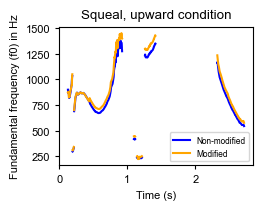

In [119]:
#### voc: SQUEAL, cond: UPWARD ####
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

X = 74

## finds start_times
print(np.unique(df_bb.loc[((df_bb["BB"] == X)), "start_times"])) #  & (df_bb["who"] == "B")

# which timing?
tt = 160.748          

#### PLOTS DIRECTLY FROM THE FILE
#BBX = df_bb.loc[((df_bb["BB"] == X) & (df_bb["start_times"] == tt) & (df_bb["who"] == "B"))]
BBX = df_bb.loc[((df_bb["BB"] == X) & (df_bb["start_times"] == tt))]
plt.figure(figsize=(2.5, 1.8))
plt.plot(BBX['timepoint'], BBX["f0_BBvoc_NM"], label="Non-modified", color='blue')
plt.plot(BBX['timepoint'], BBX["f0_BBvoc_M"], label="Modified", color='orange')
plt.title("Squeal, upward condition")
plt.xlabel("Time (s)")
plt.ylabel("Fundamental frequency (f0) in Hz")
plt.legend(loc="best")
plt.savefig(output_dir + "SQ_UP.pdf", dpi=1000, format=None, metadata=None,
           bbox_inches = "tight", pad_inches=0.1,
           facecolor='auto', edgecolor='auto',
           backend=None)
plt.savefig(output_dir + "SQ_UP.jpg", dpi=1000, format=None, metadata=None,
           bbox_inches = "tight", pad_inches=0.1,
           facecolor='auto', edgecolor='auto',
           backend=None)

[ 19.4   20.36  41.66  75.77  79.51  86.67  88.65  89.71  95.14  96.88
  99.47 106.63 108.74 111.64 118.81 119.62 122.28 123.31 126.74 134.7
 137.36 144.22 169.1  170.21 175.18]


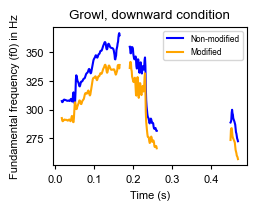

In [123]:
#### voc: GROWL, cond: DOWNWARD ####
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

X = 100

## finds start_times
print(np.unique(df_bb.loc[((df_bb["BB"] == X)), "start_times"])) #  & (df_bb["who"] == "B")

# which timing?
tt = 118.81             

#### PLOTS DIRECTLY FROM THE FILE
#BBX = df_bb.loc[((df_bb["BB"] == X) & (df_bb["start_times"] == tt) & (df_bb["who"] == "B"))]
BBX = df_bb.loc[((df_bb["BB"] == X) & (df_bb["start_times"] == tt))]
plt.figure(figsize=(2.5, 1.8))
plt.plot(BBX['timepoint'], BBX["f0_BBvoc_NM"], label="Non-modified", color='blue')
plt.plot(BBX['timepoint'], BBX["f0_BBvoc_M"], label="Modified", color='orange')
plt.title("Growl, downward condition")
plt.xlabel("Time (s)")
plt.ylabel("Fundamental frequency (f0) in Hz")
plt.legend(loc="best")
plt.savefig(output_dir + "GR_DOWN.pdf", dpi=1000, format=None, metadata=None,
           bbox_inches = "tight", pad_inches=0.1,
           facecolor='auto', edgecolor='auto',
           backend=None)
plt.savefig(output_dir + "GR_DOWN.jpg", dpi=1000, format=None, metadata=None,
           bbox_inches = "tight", pad_inches=0.1,
           facecolor='auto', edgecolor='auto',
           backend=None)

[ 0.500212  4.001695  5.848631  8.782567 11.831935 13.486482 14.458048
 16.612807 19.796848 26.241886 28.906476 30.291679 32.311765 33.889357
 36.159549 37.294645 38.670228 39.959236 41.584924 44.797824 47.597087
 49.905757 50.761889 53.137895 56.09107  57.245405 60.112004 63.161372
 65.902918 68.923429 70.558737 71.636116 74.002503 75.926395 76.994155
 79.062339 81.53454 ]


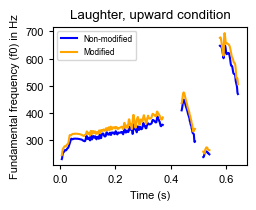

In [125]:
#### voc: LAUGHTER, cond: UPWARD ####
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

X = 119

## finds start_times
print(np.unique(df_bb.loc[((df_bb["BB"] == X)), "start_times"])) #  & (df_bb["who"] == "B")

# which timing?
tt = 68.923429                

#### PLOTS DIRECTLY FROM THE FILE
#BBX = df_bb.loc[((df_bb["BB"] == X) & (df_bb["start_times"] == tt) & (df_bb["who"] == "B"))]
BBX = df_bb.loc[((df_bb["BB"] == X) & (df_bb["start_times"] == tt))]
plt.figure(figsize=(2.5, 1.8))
plt.plot(BBX['timepoint'], BBX["f0_BBvoc_NM"], label="Non-modified", color='blue')
plt.plot(BBX['timepoint'], BBX["f0_BBvoc_M"], label="Modified", color='orange')
plt.title("Laughter, upward condition")
plt.xlabel("Time (s)")
plt.ylabel("Fundamental frequency (f0) in Hz")
plt.legend(loc="best")
plt.savefig(output_dir + "L_UP.pdf", dpi=1000, format=None, metadata=None,
           bbox_inches = "tight", pad_inches=0.1,
           facecolor='auto', edgecolor='auto',
           backend=None)
plt.savefig(output_dir + "L_UP.jpg", dpi=1000, format=None, metadata=None,
           bbox_inches = "tight", pad_inches=0.1,
           facecolor='auto', edgecolor='auto',
           backend=None)

[  2.77    4.06    5.06    6.09    6.747  16.15   17.07   18.12   35.96
  38.07   39.94   43.7    50.7    51.69   52.97   55.8    57.04   57.73
  60.22   65.32   71.216  74.41   75.9    77.59   80.12   83.9    89.33
 108.17  108.94  112.492 116.2   118.15  119.07  132.16  133.18  135.64
 138.12  140.89  142.88  148.43  152.45  165.11  166.9   179.41  182.74
 184.511 188.4   189.84  192.92  195.86  198.25  200.32  201.5   202.84
 207.    210.403 211.9   214.19  220.06  222.405 225.21  229.596 232.728
 233.493 235.055 237.32  238.39  244.68  248.52  249.52  250.79  251.84
 253.73  255.69  257.73  261.8   263.66  267.32  269.18  272.28 ]


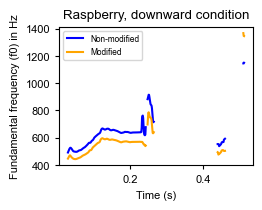

In [127]:
#### voc: RASPBERRY, cond: DOWNWARD ####
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

X = 18

## finds start_times
print(np.unique(df_bb.loc[((df_bb["BB"] == X)), "start_times"])) #  & (df_bb["who"] == "B")

# which timing?
tt = 195.86                

#### PLOTS DIRECTLY FROM THE FILE
#BBX = df_bb.loc[((df_bb["BB"] == X) & (df_bb["start_times"] == tt) & (df_bb["who"] == "B"))]
BBX = df_bb.loc[((df_bb["BB"] == X) & (df_bb["start_times"] == tt))]
plt.figure(figsize=(2.5, 1.8))
plt.plot(BBX['timepoint'], BBX["f0_BBvoc_NM"], label="Non-modified", color='blue')
plt.plot(BBX['timepoint'], BBX["f0_BBvoc_M"], label="Modified", color='orange')
plt.title("Raspberry, downward condition")
plt.xlabel("Time (s)")
plt.ylabel("Fundamental frequency (f0) in Hz")
plt.legend(loc="best")  
plt.savefig(output_dir + "RPB_DOWN.pdf", dpi=1000, format=None, metadata=None,
           bbox_inches = "tight", pad_inches=0.1,
           facecolor='auto', edgecolor='auto',
           backend=None)
plt.savefig(output_dir + "RPB_DOWN.jpg", dpi=1000, format=None, metadata=None,
           bbox_inches = "tight", pad_inches=0.1,
           facecolor='auto', edgecolor='auto',
           backend=None)

In [34]:
np.mean(BBX["f0_BBvoc_NM"])

624.367137254902

In [35]:
df_bb['f0m_NM'] = df_bb.groupby(['start_times', 'file',"who"])['f0_BBvoc_NM'].transform('mean')
np.unique(df_bb.loc[((df_bb["BB"] == X) & (df_bb["start_times"] == tt)), "f0m_NM"])

array([624.36713725])